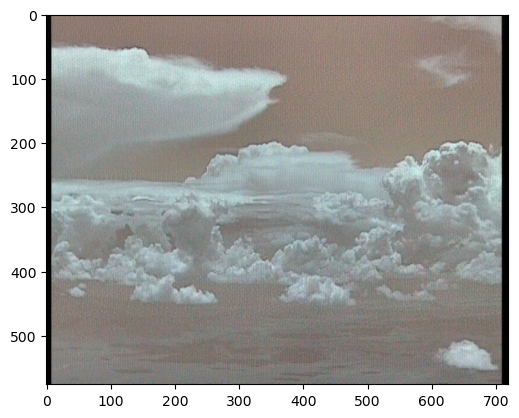

In [111]:
import cv2
import glob
import matplotlib.pyplot as plt
import os
import numpy as np

dir = '20220801/*/*' # Directory containing the images
root_dir = '20220801/'
# Load the images along with their file names
images = [(cv2.imread(file), file) for file in glob.glob(dir)]

# Convert images to grayscale
gray_images = [(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), file) for img, file in images]

# Apply thresholding
threshold = 200  # Adjust this value as needed
binary_images = [(cv2.threshold(gray_img, threshold, 255, cv2.THRESH_BINARY)[1], file) for gray_img, file in gray_images]

# Find the first image with significant sky
first_sky_image_index = None
first_sky_image_file = None
for i, (binary_img, file) in enumerate(binary_images):
    plt.imshow(images[i][0])
    
    sky_pixels = cv2.countNonZero(binary_img)
    if sky_pixels > threshold:
        first_sky_image_index = i
        first_sky_image_file = file
        if "_sky" not in file:
            new_file_name = os.path.splitext(file)[0] + "_sky" + os.path.splitext(file)[1]
            os.rename(file, new_file_name)
    else:
        if "_allcloud" not in file:
            new_file_name = os.path.splitext(file)[0] + "_allcloud" + os.path.splitext(file)[1]
            os.rename(file, new_file_name)
        


In [112]:
root_dir = '20220801/'

# Loop through all the directories in root_dir
for dir_name, sub_dirs, files in os.walk(root_dir):
    if dir_name == root_dir:
        continue    
    # Check if the directory contains only files with the "_allcloud" tag
    allcloud_files = glob.glob(os.path.join(dir_name, "*_allcloud.*"))
    if len(files) == len(allcloud_files):
        print("Directory containing only '_allcloud' files:", dir_name)
        if "_allcloud" not in dir_name:
            new_dir_name = dir_name + "_allcloud"
            os.rename(dir_name, new_dir_name)

Directory containing only '_allcloud' files: 20220801/pass_330_b_181130_rfc
Directory containing only '_allcloud' files: 20220801/pass_345_c_192043_rfc
Directory containing only '_allcloud' files: 20220801/pass_345_b_192000_rfc
Directory containing only '_allcloud' files: 20220801/pass_346_a_192455_rfc
Directory containing only '_allcloud' files: 20220801/pass_344_a_191327_rfc
Directory containing only '_allcloud' files: 20220801/pass_350_a_193841_rfc
Directory containing only '_allcloud' files: 20220801/pass_344_b_191343_rfc
Directory containing only '_allcloud' files: 20220801/pass_340_185810_rfc
Directory containing only '_allcloud' files: 20220801/pass_348_a_193341_rfc
Directory containing only '_allcloud' files: 20220801/pass_341_190155_rfc
Directory containing only '_allcloud' files: 20220801/pass_347_a_192934_rfc
Directory containing only '_allcloud' files: 20220801/pass_346_d_192704_rfc
Directory containing only '_allcloud' files: 20220801/pass_345_a_191938_rfc
Directory contai

In [113]:
import cv2
import numpy as np
import glob
import os

dir = '20220801/*/*_sky.*' # Directory containing the images

# Load the images along with their file names
images = [(cv2.imread(file), file) for file in glob.glob(dir)]

for img, file in images:
    # Convert the image from BGR to HSV color space
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define range for blue color in HSV
    lower_blue = np.array([110,50,50])
    upper_blue = np.array([130,255,255])

    # Threshold the HSV image to get only blue colors
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Count the number of blue pixels
    blue_pixels = cv2.countNonZero(mask)

    # If the image has more than 20000 blue pixels, rename it to include the "_bluesky" tag
    if blue_pixels > 10000:
        if "_bluesky" not in file:
            new_file_name = os.path.splitext(file)[0] + "_bluesky" + os.path.splitext(file)[1]
            os.rename(file, new_file_name)

In [114]:
import xarray as xr
import pandas as pd
#dataset = xr.open_dataset('core_faam_20220726_v005_r0_c304.nc')
#dataset = xr.open_dataset('core_faam_20220725_v005_r0_c303.nc')
dataset = xr.open_dataset('core_faam_20220801_v005_r0_c309.nc') 
roll =dataset['ROLL_GIN']
roll_times = roll.Time
roll_angle = roll.data[:,1]
roll_times_pd = pd.to_datetime(roll_times.data)

roll_df = pd.DataFrame({'roll_times': roll_times_pd, 'roll_angles': roll_angle})

In [115]:
def extract_timestamp_from_sub_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[4]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(roll_df['roll_times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return roll_df.loc[min_diff_index, 'roll_angles']    

In [116]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import glob
import cv2
import re
import os
import numpy as np
from PIL import Image

root_dir = '20220801/'

# Define the key function to extract the date and timestamp from the file name
def get_datetime_from_filename(file):
    match = re.search(r'frame_c309_(\d{8})_(\d{6})', file)
    if match:
        date = match.group(1)
        
        timestamp = match.group(2)
        
        return int(date + timestamp)
    else:
        print("No match")
        return 0



# Loop through all the directories in root_dir
for dir_name, sub_dirs, files in os.walk(root_dir):
    subdir_name = os.path.basename(dir_name)
    
    # Get all the images in the directory
    image_files = glob.glob(os.path.join(dir_name, "*.png"))  # Adjust the file extension as needed
 
    image_files.sort(key=lambda f: re.search(r'(\d{6})_\w+', f).group(1) if re.search(r'(\d{6})_\w+', f) else '')
    # Sort the image files based on the extracted datetime
    image_files = sorted(image_files, key=get_datetime_from_filename)
   
    # Create a new figure for the directory
    fig = plt.figure(figsize=(10, 10))
    
   

    # Calculate the number of rows and columns based on the number of images
    num_images = len(image_files)
    num_rows = (num_images + 4) // 5  # Adjust the grid size as needed
    num_cols = min(num_images, 5)
    
    
    # Loop through the images and add them to the figure
    for i, file in enumerate(image_files):
        
        if len(file.split('/'))==2:
            print(file)
            continue
            
        try:
            [camera, frame_time] = extract_timestamp_from_filename(file)
        except IndexError:
            [camera, frame_time] = extract_timestamp_from_sub_filename(file)
        
        
        roll = get_closest_roll_angle(frame_time)
        img = Image.open(file)
        img.thumbnail((800, 800))  # Adjust the size as needed
        img = np.array(img)
        
       
        
        # If the image name includes the tag "_bluesky", add a green border to the image
        if "_bluesky" in file:
            border_color = (0, 255, 0)  # Green color
            border_width = 20
            img = cv2.copyMakeBorder(img, border_width, border_width, border_width, border_width, 
                                     cv2.BORDER_CONSTANT, value=border_color)
            #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = fig.add_subplot(num_rows, num_cols, i+1)
        ax.imshow(img)
         # Display the roll_angle
        # Calculate line coordinates for roll angle
        if camera == 'ffc':
            angle_rad = -np.deg2rad(roll)
        else:
            angle_rad = np.deg2rad(roll)
       
        line_length = img.shape[1] / 2
        x = [img.shape[1] / 2 - line_length * np.cos(angle_rad), img.shape[1] / 2 + line_length * np.cos(angle_rad)]
        y = [img.shape[0] / 2  - line_length * np.sin(angle_rad), img.shape[0] / 2 + line_length * np.sin(angle_rad)]
        ax.plot(x, y, 'r--', linewidth=1, alpha=0.2)
        ax.axis('off')
        
       

       
    # save figure
    if num_images > 0:
        
        # Set the title for the whole plot
        #plt.suptitle(subdir_name)
        # Set the title for the whole plot
        fig.suptitle(subdir_name, fontsize=16)
        plt.tight_layout()
        fig.subplots_adjust(top=0.88)
        plt.savefig(root_dir+'/' + subdir_name + '.png')
        plt.close(fig)
        
    

    

<Figure size 1000x1000 with 0 Axes>

In [76]:
print(root_dir+'/' + subdir_name + '.png')

20220727//.png
